# Notebook 02 — Statistical Analysis

**Reads from `outputs/` (produced by Notebook 01):**
- `dfm_merged.csv`, `metadata_numerical.csv`, `wide_scaled_imputed.csv`

**Analyses:**
1. Group comparison box/strip plots with significance brackets
2. PCA (Plasma & CSF, optionally excluding a platform keyword)
3. OLS volcano plots with FDR correction (multiple covariate specs)

**Outputs:**
- `outputs/analyte_plots_8x2.pptx` (or PNGs)
- Volcano + PCA figures displayed inline

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import io, os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.multitest import multipletests
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("⚠ statsmodels not installed — volcano plots will use scipy t-tests instead of OLS")

from config import *
from utils import (
    welch_t_trimmed_safe, p_to_stars, plot_analyte_box,
    build_feature_matrix, clean_labels
)

In [2]:
dfm = pd.read_csv(OUTPUT_DIR / "dfm_merged.csv")
metadata_numerical = pd.read_csv(OUTPUT_DIR / "metadata_numerical.csv")
final_wide_imputed = pd.read_csv(OUTPUT_DIR / "wide_scaled_imputed.csv")

# Identify analyte columns
meta_col_set = set(metadata_numerical.columns)
analyte_cols_all = [c for c in dfm.columns if c not in meta_col_set]
plasma_cols = [c for c in analyte_cols_all if c.endswith("_Plasma")]
csf_cols    = [c for c in analyte_cols_all if c.endswith("_CSF")]

# Numeric analyte columns only
analyte_cols_num = [c for c in analyte_cols_all if pd.to_numeric(dfm[c], errors="coerce").notna().any()]

print(f"Donors: {len(dfm)}  |  Analytes: {len(analyte_cols_num)}  (Plasma: {len(plasma_cols)}, CSF: {len(csf_cols)})")

Donors: 80  |  Analytes: 37  (Plasma: 21, CSF: 16)


## 1 · Box + Strip Plots with Significance Brackets

8×2 grid pages, comparing case vs control for each analyte.

In [3]:
sns.set(style="whitegrid", context="talk")
order = [CONTROL_LABEL, CASE_LABEL]

def build_figure_page(cols_16, df, group_col, order, fig_size=(17, 7.5)):
    fig, axes = plt.subplots(nrows=2, ncols=8, figsize=fig_size, constrained_layout=True)
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(cols_16):
            plot_analyte_box(ax, df, cols_16[i], group_col, order, palette=PALETTE)
        else:
            ax.axis("off")
    return fig

def fig_to_buf(fig, dpi=FIG_DPI):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return buf

# Paginate analytes
plots_per_page = PLOTS_PER_PAGE
pages = [analyte_cols_num[i:i+plots_per_page]
         for i in range(0, len(analyte_cols_num), plots_per_page)]

fig_bufs = []
for cols16 in pages:
    fig = build_figure_page(cols16, dfm, GROUP_COL, order)
    fig_bufs.append(fig_to_buf(fig))

# Export
if EXPORT_PPTX:
    try:
        from pptx import Presentation
        from pptx.util import Inches

        prs = Presentation()
        prs.slide_width = Inches(13.333)
        prs.slide_height = Inches(7.5)
        blank = prs.slide_layouts[6]

        margin = Inches(0.3)
        usable_w = prs.slide_width - 2 * margin
        usable_h = prs.slide_height - 2 * margin

        for buf in fig_bufs:
            slide = prs.slides.add_slide(blank)
            pic = slide.shapes.add_picture(buf, margin, margin, width=usable_w)
            if pic.height > usable_h:
                scale = usable_h / pic.height
                pic.height = usable_h
                pic.width = int(pic.width * scale)
                pic.left = margin + int((usable_w - pic.width) / 2)

        out_path = OUTPUT_DIR / "analyte_plots_8x2.pptx"
        prs.save(str(out_path))
        print(f"✓ Saved PowerPoint: {out_path} ({len(fig_bufs)} slides)")
    except ImportError:
        print("⚠ python-pptx not installed — saving PNGs instead")
        EXPORT_PPTX = False

if not EXPORT_PPTX:
    png_dir = OUTPUT_DIR / "box_plots"
    png_dir.mkdir(exist_ok=True)
    for idx, buf in enumerate(fig_bufs, 1):
        with open(png_dir / f"page_{idx:02d}.png", "wb") as f:
            f.write(buf.getvalue())
    print(f"✓ Saved {len(fig_bufs)} PNGs to {png_dir}")

⚠ python-pptx not installed — saving PNGs instead
✓ Saved 3 PNGs to outputs/box_plots


## 2 · PCA — Plasma & CSF (excluding platform keyword if set)

In [4]:
def prep_matrix(df, cols, exclude_keyword=None):
    """Prepare a numeric matrix: exclude keyword, drop all-NaN / constant cols, impute."""
    if exclude_keyword:
        cols = [c for c in cols if exclude_keyword not in c.lower()]
    X = df[cols].apply(pd.to_numeric, errors="coerce")
    drop = list(X.columns[X.isna().all()]) + list(X.columns[X.nunique(dropna=True) <= 1])
    if drop:
        X = X.drop(columns=drop)
    X = X.fillna(X.median())
    return X

def run_pca_and_plot(df, cols, title_prefix, n_pairs=9):
    from sklearn.decomposition import PCA as _PCA

    X_imp = prep_matrix(df, cols, exclude_keyword=EXCLUDE_PLATFORM_KEYWORD)
    if X_imp.shape[1] < 2:
        print(f"{title_prefix}: Not enough informative columns for PCA.")
        return

    pca = _PCA(n_components=min(10, X_imp.shape[1]))
    scores = pca.fit_transform(X_imp)
    scores_df = pd.DataFrame(scores, columns=[f"PC{i+1}" for i in range(scores.shape[1])], index=df.index)
    scores_df[ID_COL] = df[ID_COL]
    scores_df[GROUP_COL] = df[GROUP_COL]

    n_components = scores_df.filter(regex=r"^PC\d+$").shape[1]
    pairs_to_plot = min(n_pairs, max(0, n_components - 1))
    if pairs_to_plot == 0:
        print(f"{title_prefix}: Fewer than 2 components.")
        return

    sns.set(style="whitegrid", context="talk")
    rows, cols_grid = 3, 3
    fig, axes = plt.subplots(rows, cols_grid, figsize=(15, 12), sharex=False, sharey=False)
    axes = axes.flatten()

    legend_ax = None
    for i in range(pairs_to_plot):
        pc_x, pc_y = f"PC{i+1}", f"PC{i+2}"
        ax = axes[i]
        show_legend = (legend_ax is None)
        sns.scatterplot(data=scores_df, x=pc_x, y=pc_y,
                        hue=GROUP_COL, style=GROUP_COL, palette=PALETTE,
                        s=50, ax=ax, legend=show_legend)
        if show_legend:
            legend_ax = ax
        ax.set_xlabel(pc_x)
        ax.set_ylabel(pc_y)
        evr_x = pca.explained_variance_ratio_[i]
        evr_y = pca.explained_variance_ratio_[i+1]
        ax.set_title(f"{pc_x} ({evr_x:.1%}) vs {pc_y} ({evr_y:.1%})")

    for j in range(pairs_to_plot, rows * cols_grid):
        axes[j].axis("off")

    if legend_ax is not None:
        handles, labels = legend_ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

    excl = f", excluding {EXCLUDE_PLATFORM_KEYWORD.title()}" if EXCLUDE_PLATFORM_KEYWORD else ""
    fig.suptitle(f"{title_prefix} PCA ({CASE_LABEL} + {CONTROL_LABEL}{excl})",
                 y=0.98, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # Loadings
    loadings = pd.DataFrame(pca.components_.T, index=X_imp.columns,
                            columns=[f"PC{i+1}" for i in range(scores.shape[1])])
    top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(15)
    print(f"\nTop PC1 loadings — {title_prefix}{excl}:")
    print(top_pc1)

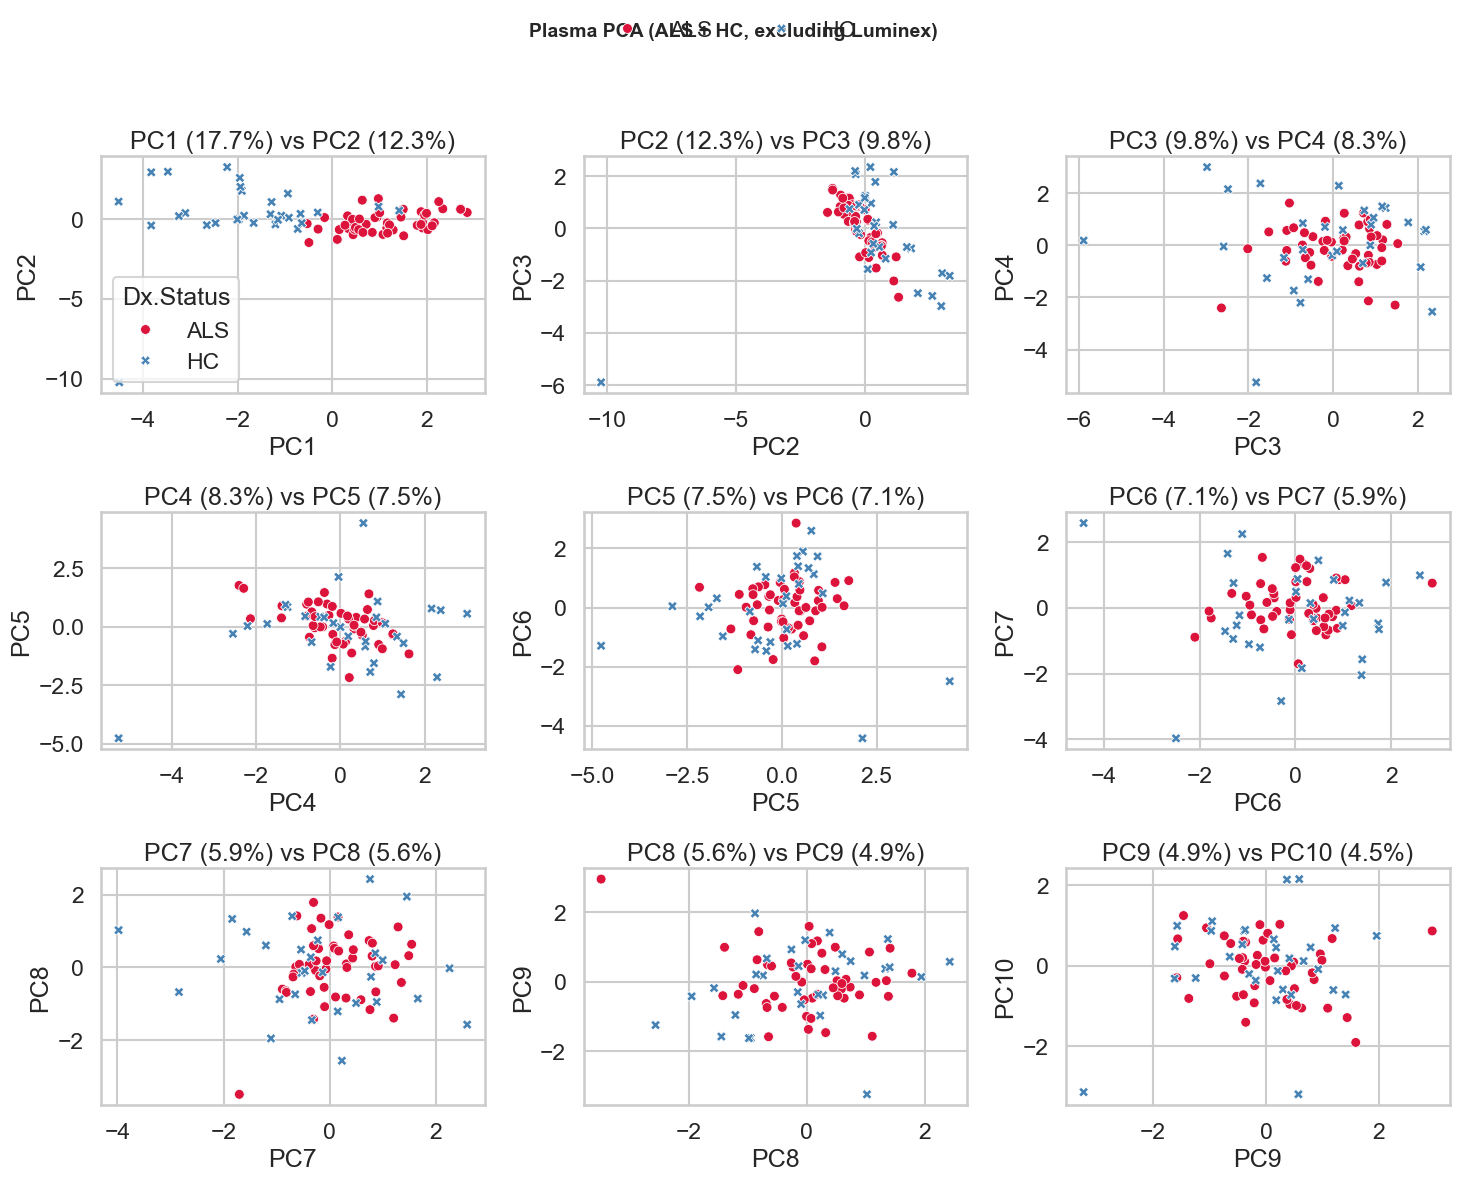


Top PC1 loadings — Plasma, excluding Luminex:
Quanterix_GFAP_Plasma    0.382447
AB42/AB40_Plasma         0.372330
ELISA_AB40_Plasma        0.334335
Vplex1_BM-I_Plasma       0.297274
Uplex1_BM-F_Plasma       0.265601
ELISA_AB42_Plasma        0.260132
ELISA_BM-B_Plasma        0.241495
Quanterix_NfL_Plasma     0.221804
Vplex1_BM-H_Plasma       0.196037
ELISA_BM-D_Plasma        0.195897
Vplex1_BM-J_Plasma       0.192775
ELISA_CHIT1_Plasma       0.188259
ELISA_BM-C_Plasma        0.178449
ELISA_BM-A_Plasma        0.168801
Uplex1_IL-18_Plasma      0.143282
Name: PC1, dtype: float64


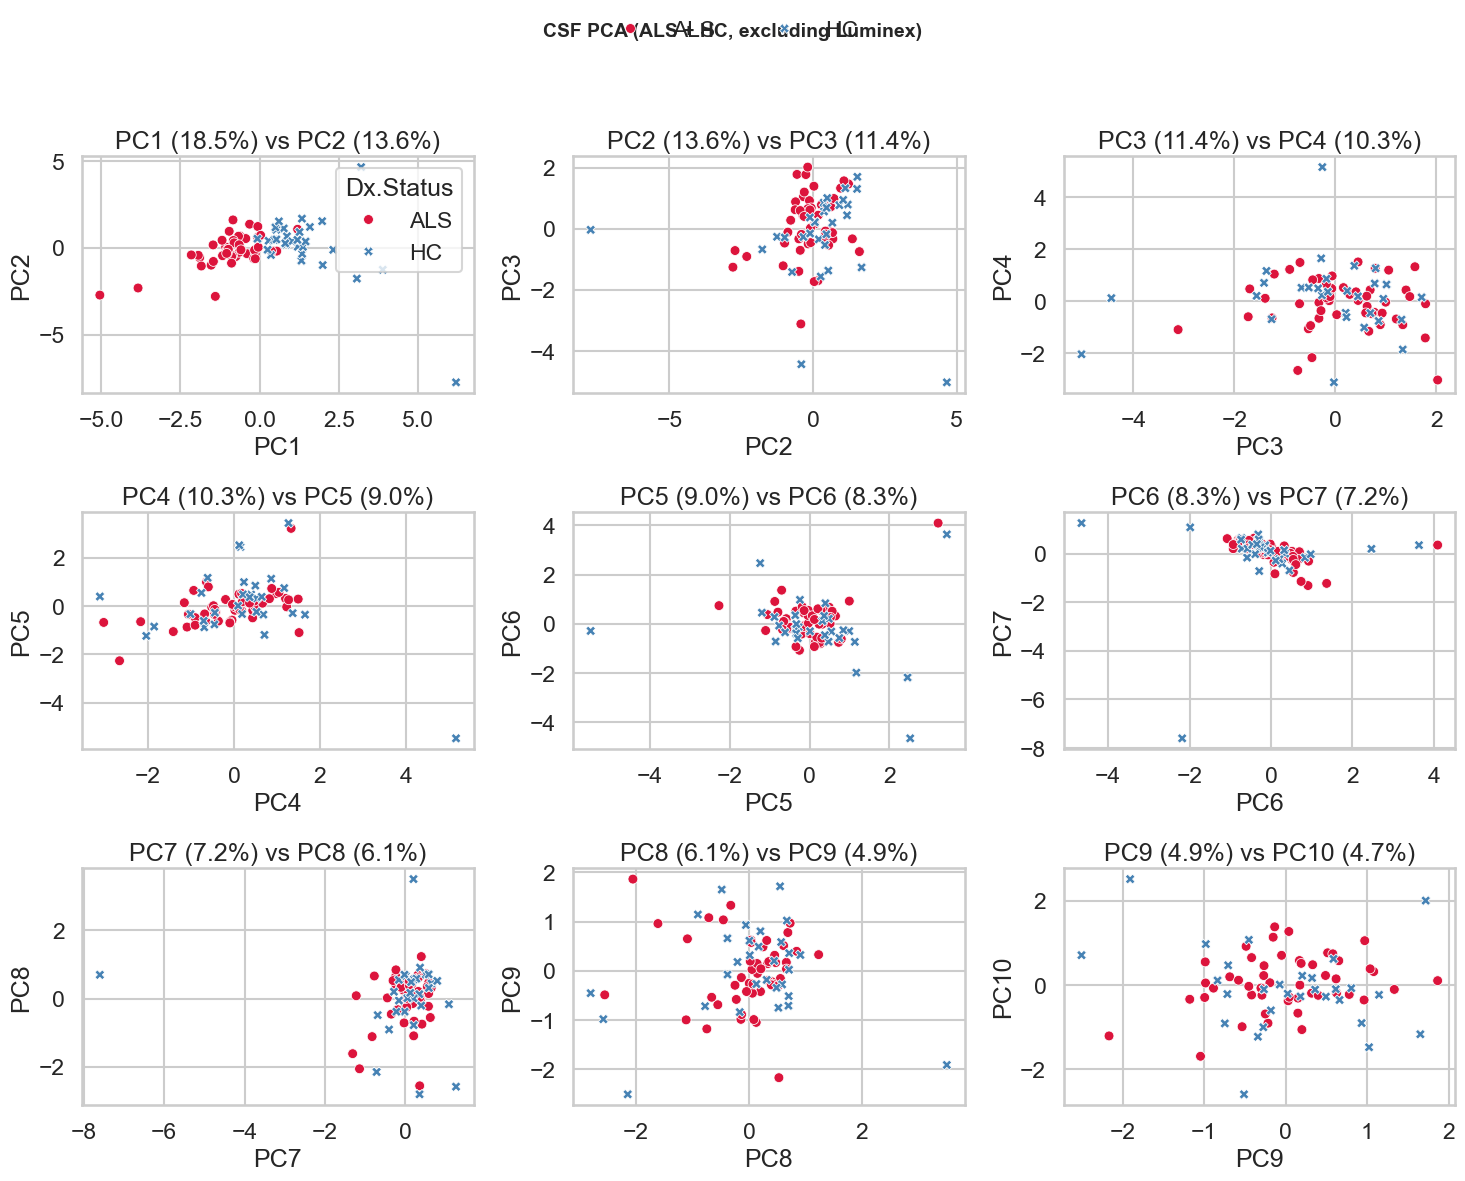


Top PC1 loadings — CSF, excluding Luminex:
ELISA_AB42_CSF        0.528867
AB42/AB40_CSF         0.458114
Quanterix_NfL_CSF     0.385777
Splex1_IL-6_CSF       0.319926
Uplex3_IL-18_CSF      0.231503
ELISA_AB40_CSF        0.229187
ELISA_BM-A_CSF        0.207912
Uplex1_BM-N_CSF       0.198585
Quanterix_GFAP_CSF    0.187878
ELISA_CHIT1_CSF       0.135358
ELISA_BM-E_CSF        0.105392
ELISA_BM-D_CSF        0.059930
Uplex3_BM-F_CSF       0.046393
Name: PC1, dtype: float64


In [5]:
# Filter to case + control only
df_use = dfm[dfm[GROUP_COL].isin([CASE_LABEL, CONTROL_LABEL])].copy()

if len(plasma_cols) > 0:
    run_pca_and_plot(df_use, plasma_cols, title_prefix="Plasma")
if len(csf_cols) > 0:
    run_pca_and_plot(df_use, csf_cols, title_prefix="CSF")

## 3 · Volcano Plots — OLS regression with FDR correction

For each covariate specification, fit `analyte ~ group_bin + covariates`
per analyte and plot effect size vs −log10(p_adj).

In [6]:
# Merge features + metadata
df_features = final_wide_imputed.copy()
df_meta = metadata_numerical.copy()
dfm_vol = pd.merge(df_meta, df_features, on=ID_COL, how="inner")

# Binary group indicator
dfm_vol["group_bin"] = (dfm_vol[GROUP_COL] == CASE_LABEL).astype(int)

# Identify analyte columns
exclude_cols = {
    ID_COL, GROUP_COL, "group_bin", "Sex_num", "Age",
    "Site_of_Onset_num", "Dx.Detailed_num", "Dx.Mutation_num",
    "El_Escorial_num", "Radicava", "Rilutek", "Tofersen", "ALSFRSR"
}
vol_analyte_cols_all = [c for c in df_features.columns if c not in exclude_cols and c != ID_COL]
vol_plasma_cols = [c for c in vol_analyte_cols_all if c.endswith("_Plasma")]
vol_csf_cols    = [c for c in vol_analyte_cols_all if c.endswith("_CSF")]

In [7]:
# Build PC1, PC2 from all analytes for use as covariates
X_for_pca = dfm_vol[vol_analyte_cols_all].apply(pd.to_numeric, errors="coerce")
X_for_pca = X_for_pca.fillna(X_for_pca.mean())
if X_for_pca.shape[1] >= 2:
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_for_pca.values)
    dfm_vol["PC1"] = pcs[:, 0]
    dfm_vol["PC2"] = pcs[:, 1]
else:
    dfm_vol["PC1"] = 0.0
    dfm_vol["PC2"] = 0.0

# Standardise continuous covariates
for c in ["Age", "PC1", "PC2"]:
    if c in dfm_vol.columns:
        x = pd.to_numeric(dfm_vol[c], errors="coerce")
        mu, sd = x.mean(), x.std(ddof=0)
        if np.isfinite(sd) and sd > 0:
            dfm_vol[c] = (x - mu) / sd

In [8]:
def fit_ols_volcano(df, analyte_cols, covariates, robust=USE_ROBUST_SE):
    """Fit per-analyte OLS (if statsmodels available) or Welch t-test as fallback."""
    rows = []
    for analyte in analyte_cols:
        if HAS_STATSMODELS and covariates:
            formula = f'Q("{analyte}") ~ group_bin' + "".join(
                [f' + Q("{c}")' if not c.isidentifier() else f" + {c}" for c in covariates]
            )
            try:
                fit = smf.ols(formula, data=df).fit(cov_type="HC3" if robust else "nonrobust")
                coef = fit.params.get("group_bin", np.nan)
                pval = fit.pvalues.get("group_bin", np.nan)
                rows.append({"analyte": analyte, "effect": coef, "pval": pval})
                continue
            except Exception:
                pass

        # Fallback: simple group difference
        case = pd.to_numeric(df.loc[df["group_bin"] == 1, analyte], errors="coerce").dropna()
        ctrl = pd.to_numeric(df.loc[df["group_bin"] == 0, analyte], errors="coerce").dropna()
        if len(case) >= 2 and len(ctrl) >= 2:
            from scipy.stats import ttest_ind
            stat, pval = ttest_ind(case, ctrl, equal_var=False)
            coef = case.mean() - ctrl.mean()
        else:
            coef, pval = np.nan, np.nan
        rows.append({"analyte": analyte, "effect": coef, "pval": pval})

    out = pd.DataFrame(rows)
    out["neg_log10_p"] = -np.log10(out["pval"])
    return out


def apply_fdr(df_vol):
    """Apply Benjamini-Hochberg FDR correction."""
    if HAS_STATSMODELS:
        if not df_vol.empty and df_vol["pval"].notna().any():
            mask = df_vol["pval"].notna()
            _, p_adj, _, _ = multipletests(df_vol.loc[mask, "pval"], method="fdr_bh")
            df_vol.loc[mask, "pval_adj"] = p_adj
            df_vol["neg_log10_p_adj"] = -np.log10(df_vol["pval_adj"])
        else:
            if not df_vol.empty:
                df_vol["pval_adj"] = np.nan
                df_vol["neg_log10_p_adj"] = np.nan
    else:
        # Simple Bonferroni fallback
        if not df_vol.empty and df_vol["pval"].notna().any():
            n_tests = df_vol["pval"].notna().sum()
            df_vol["pval_adj"] = np.minimum(df_vol["pval"] * n_tests, 1.0)
            df_vol["neg_log10_p_adj"] = -np.log10(df_vol["pval_adj"])
        else:
            if not df_vol.empty:
                df_vol["pval_adj"] = np.nan
                df_vol["neg_log10_p_adj"] = np.nan
    return df_vol


def plot_volcano(df_vol, title, subtitle, alpha=ALPHA, use_adj=True):
    if df_vol.empty:
        print(f"{title} — {subtitle}: No analytes to plot.")
        return
    pcol = "pval_adj" if use_adj and "pval_adj" in df_vol.columns else "pval"
    ycol = "neg_log10_p_adj" if pcol == "pval_adj" else "neg_log10_p"
    sig_mask = df_vol[pcol] < alpha

    sns.set(style="whitegrid")
    plt.figure(figsize=(9, 7))
    ax = sns.scatterplot(data=df_vol, x="effect", y=ycol, hue=sig_mask,
                         palette={True: "crimson", False: "steelblue"}, legend=False)
    ax.axhline(-np.log10(alpha), color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Effect size (case vs control)")
    ax.set_ylabel(f"-log10({pcol})")
    ax.set_title(f"{title}\n{subtitle}")

    # Label significant analytes
    for _, row in df_vol[sig_mask].iterrows():
        ax.text(row["effect"], row[ycol], row["analyte"], fontsize=8,
                ha="left", va="bottom")

    plt.tight_layout()
    plt.show()

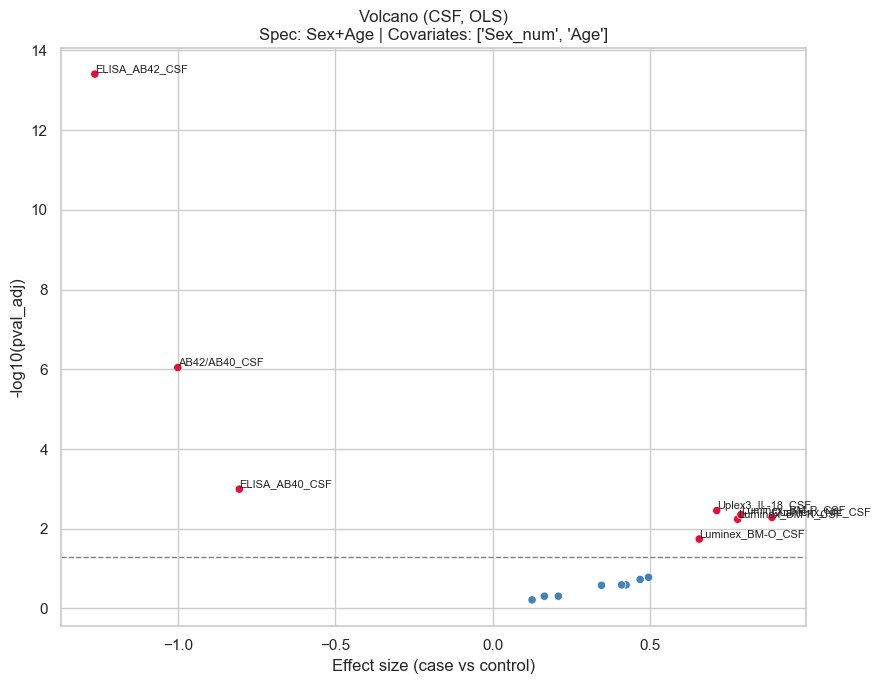

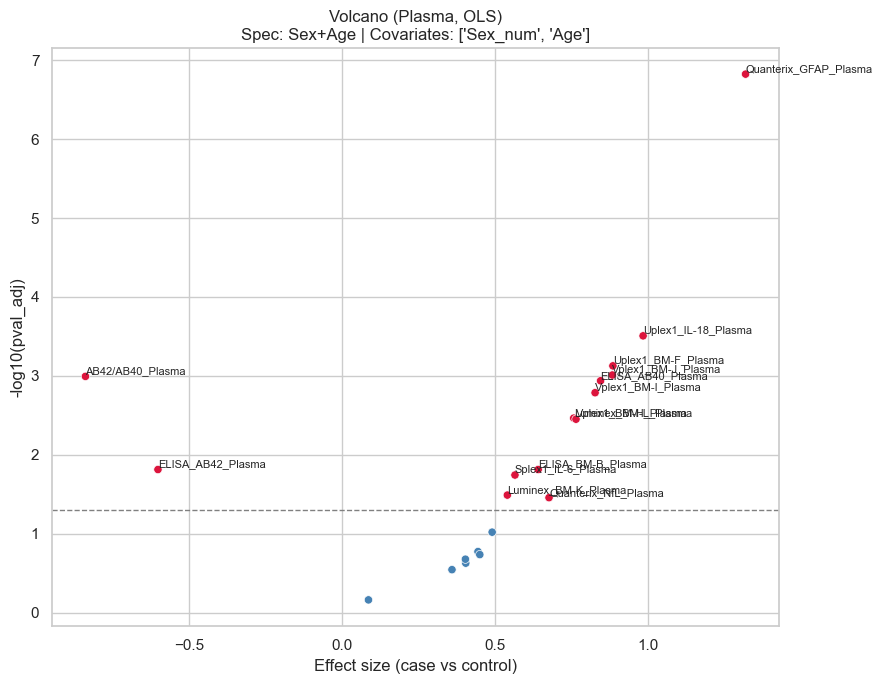

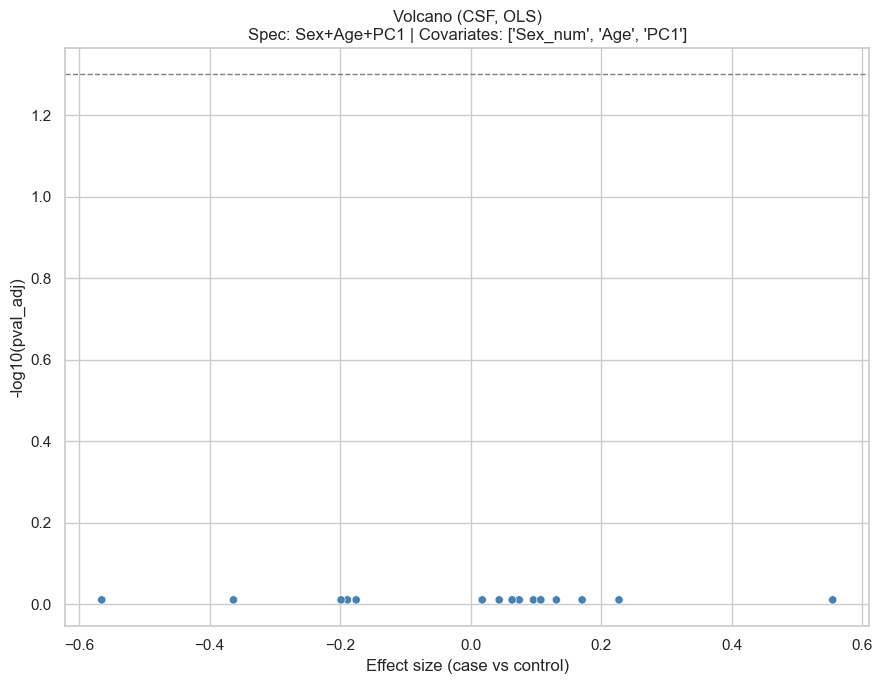

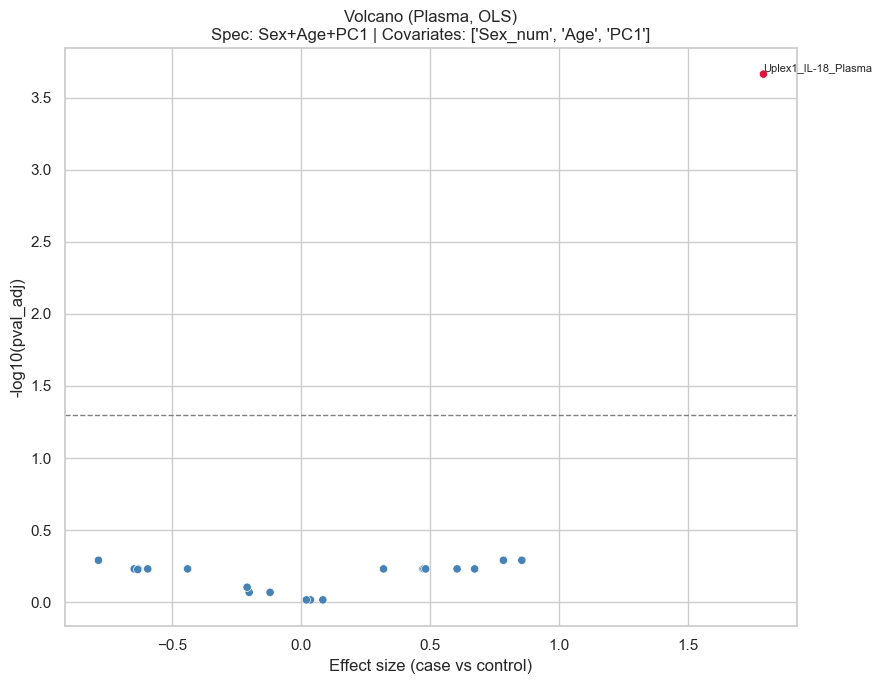

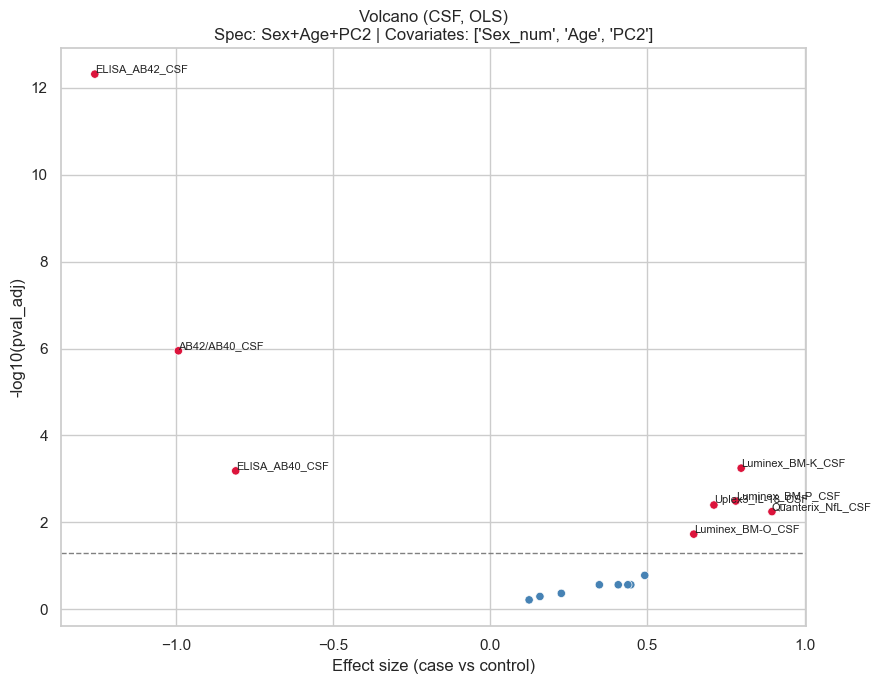

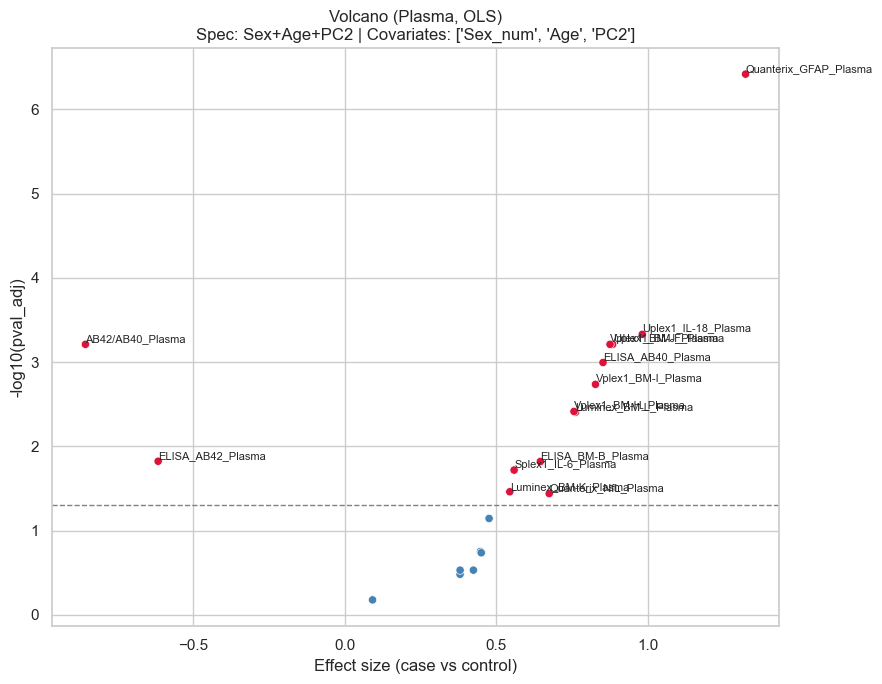

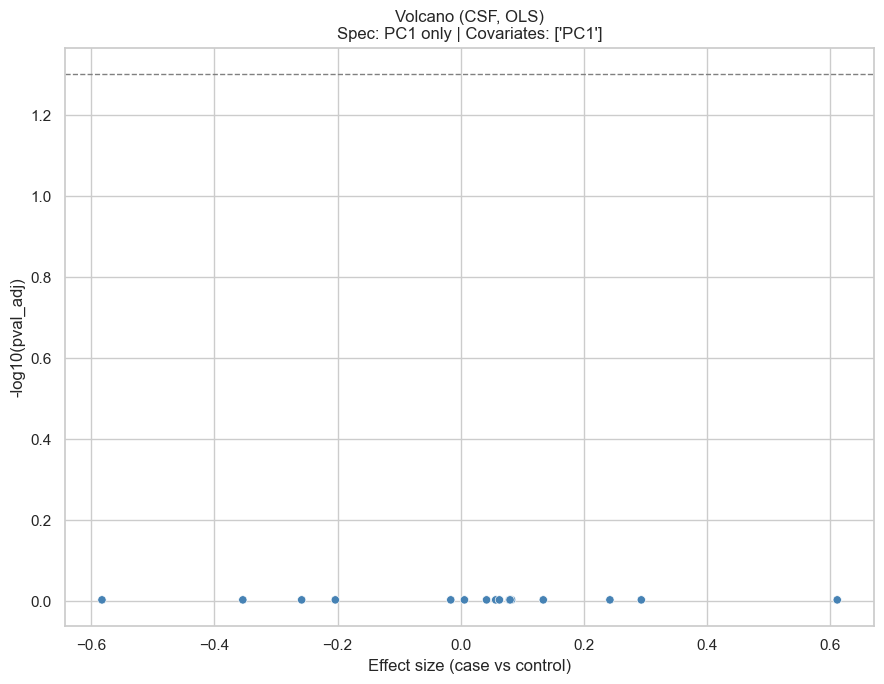

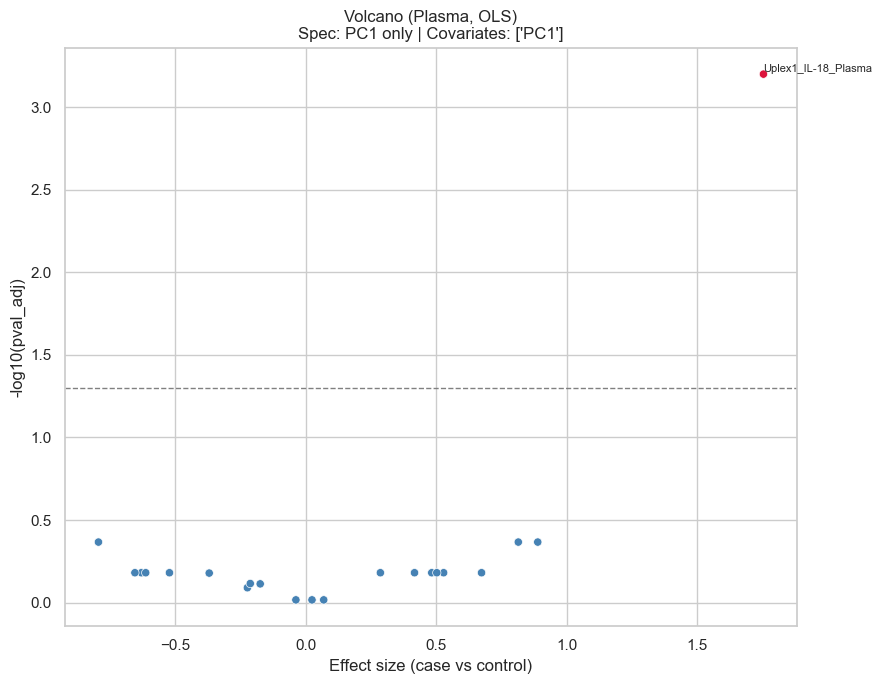

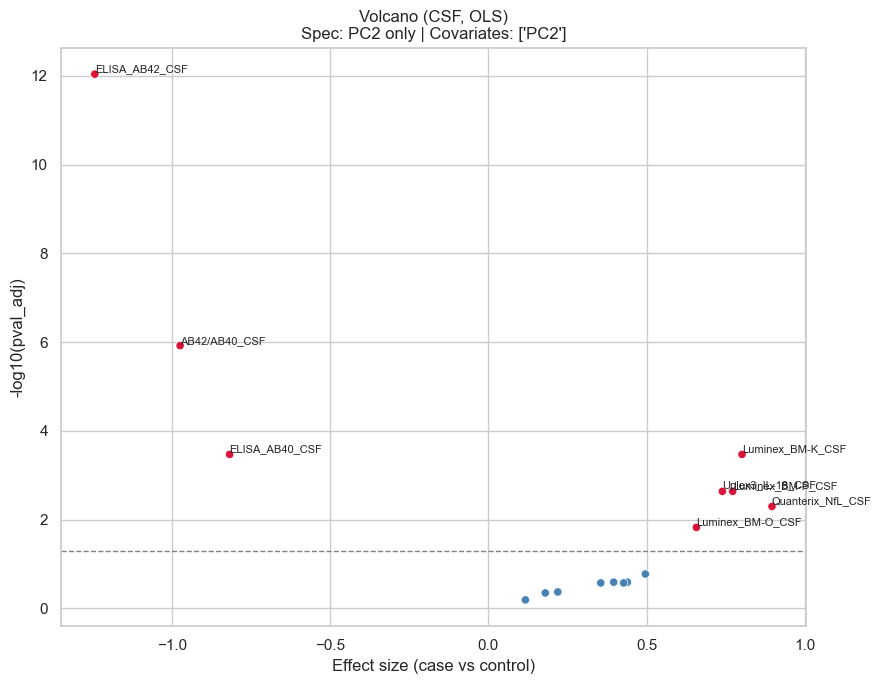

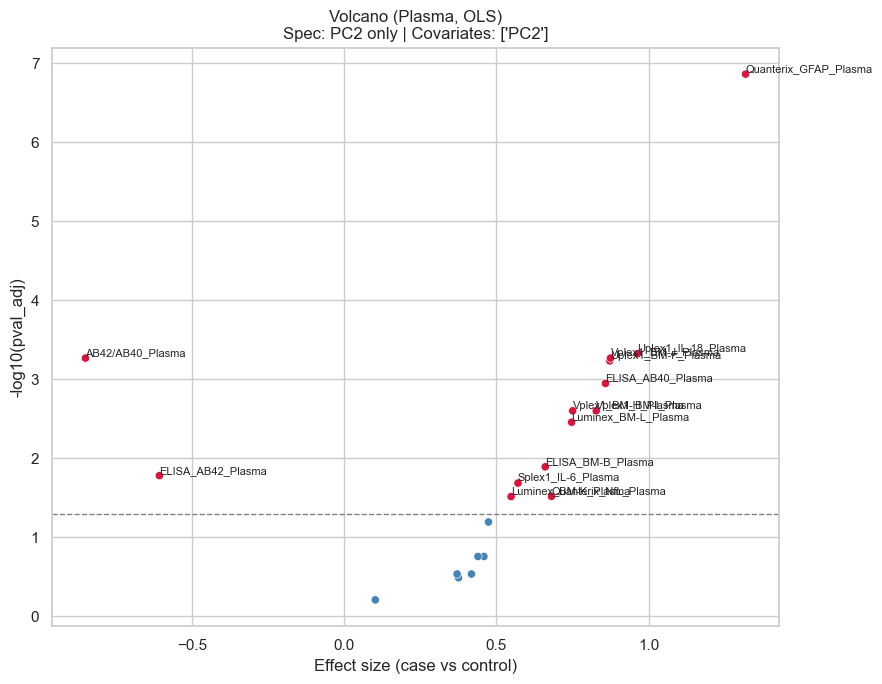

In [9]:
results = {}
for spec_name, covs in VOLCANO_SPECS.items():
    # Check covariates exist
    available_covs = [c for c in covs if c in dfm_vol.columns]
    if not available_covs:
        print(f"⚠ Skipping spec '{spec_name}': no covariates available")
        continue

    volcano_csf = fit_ols_volcano(dfm_vol, vol_csf_cols, available_covs)
    volcano_plasma = fit_ols_volcano(dfm_vol, vol_plasma_cols, available_covs)

    # FDR correction
    volcano_csf = apply_fdr(volcano_csf)
    volcano_plasma = apply_fdr(volcano_plasma)

    results[spec_name] = {"csf": volcano_csf, "plasma": volcano_plasma}

    plot_volcano(volcano_csf, "Volcano (CSF, OLS)",
                 f"Spec: {spec_name} | Covariates: {available_covs}")
    plot_volcano(volcano_plasma, "Volcano (Plasma, OLS)",
                 f"Spec: {spec_name} | Covariates: {available_covs}")

### Specification summaries

In [10]:
def summarize(df_vol, alpha=ALPHA):
    if df_vol.empty:
        return {"n_models": 0, "n_sig": 0}
    n_models = len(df_vol)
    n_sig = int(np.sum((df_vol["pval_adj"].notna()) & (df_vol["pval_adj"] < alpha)))
    return {"n_models": n_models, "n_sig": n_sig}

print("\nSpecification summaries (OLS):")
for spec_name, d in results.items():
    csf_sum = summarize(d["csf"])
    plasma_sum = summarize(d["plasma"])
    print(f"  {spec_name}: "
          f"CSF [models={csf_sum['n_models']}, FDR<{ALPHA}={csf_sum['n_sig']}], "
          f"Plasma [models={plasma_sum['n_models']}, FDR<{ALPHA}={plasma_sum['n_sig']}]")


Specification summaries (OLS):
  Sex+Age: CSF [models=16, FDR<0.05=8], Plasma [models=21, FDR<0.05=14]
  Sex+Age+PC1: CSF [models=16, FDR<0.05=0], Plasma [models=21, FDR<0.05=1]
  Sex+Age+PC2: CSF [models=16, FDR<0.05=8], Plasma [models=21, FDR<0.05=14]
  PC1 only: CSF [models=16, FDR<0.05=0], Plasma [models=21, FDR<0.05=1]
  PC2 only: CSF [models=16, FDR<0.05=8], Plasma [models=21, FDR<0.05=14]
